In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd

In [ ]:
src = 'my_typing_data.csv'

In [ ]:
table = pd.read_csv(src)

timestamps_sample = table['timestamp'].to_numpy()
states_sample =  table['token'].to_numpy()
categories = {0: 'letter', 1: 'space', 2: 'enter', 3: 'punctuation'}

print(timestamps_sample)
print(states_sample)

count = len(categories)

[     0    987   1116 ... 509497 509670 509821]
[0 1 0 ... 0 0 3]


In [ ]:
def transition_code(state1, state2):
  return state1 + state2 * count

def from_transition_code(code):
  return int(code % count), code // count

data = []

for i in range(count**2):
  data.append([])

for index in range(len(states_sample) - 1):
  code = transition_code(states_sample[index], states_sample[index + 1])
  transition_time = timestamps_sample[index + 1] - timestamps_sample[index]
  data[code].append(transition_time)

(4, 4)


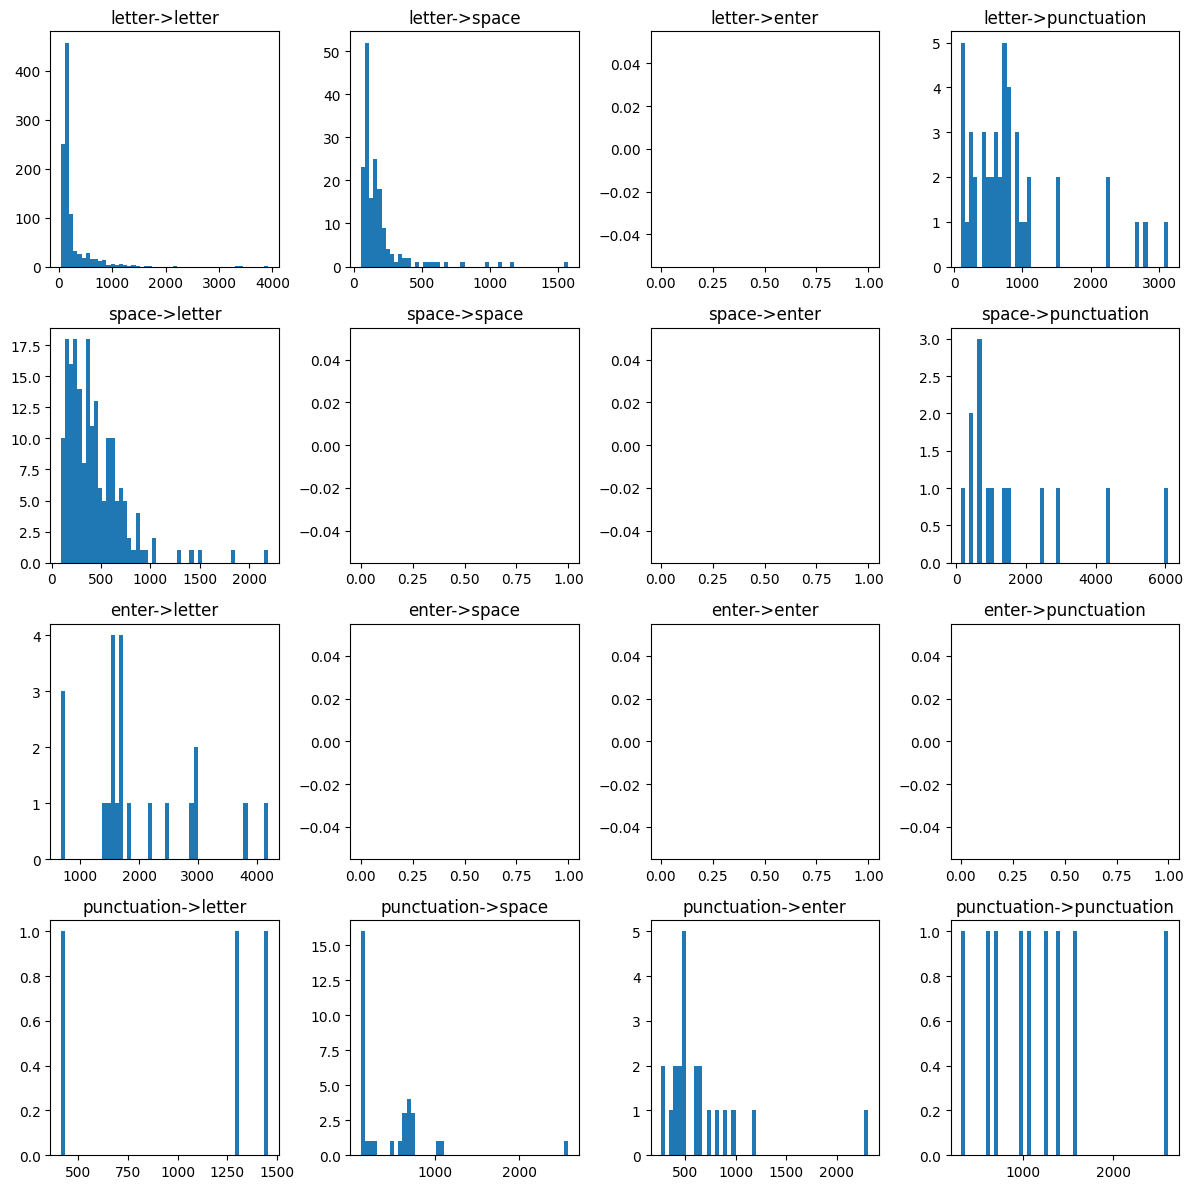

In [ ]:
fig, axes = plt.subplots(count, count, figsize=(12, 12))

print(axes.shape)

for code in range(len(data)):
  i, j = from_transition_code(code)
  axes[i, j].set_title(str(categories[i]) + '->' + str(categories[j]))
  axes[i, j].hist(data[code], bins = 50)

plt.tight_layout()
plt.show()

Plot the CDF

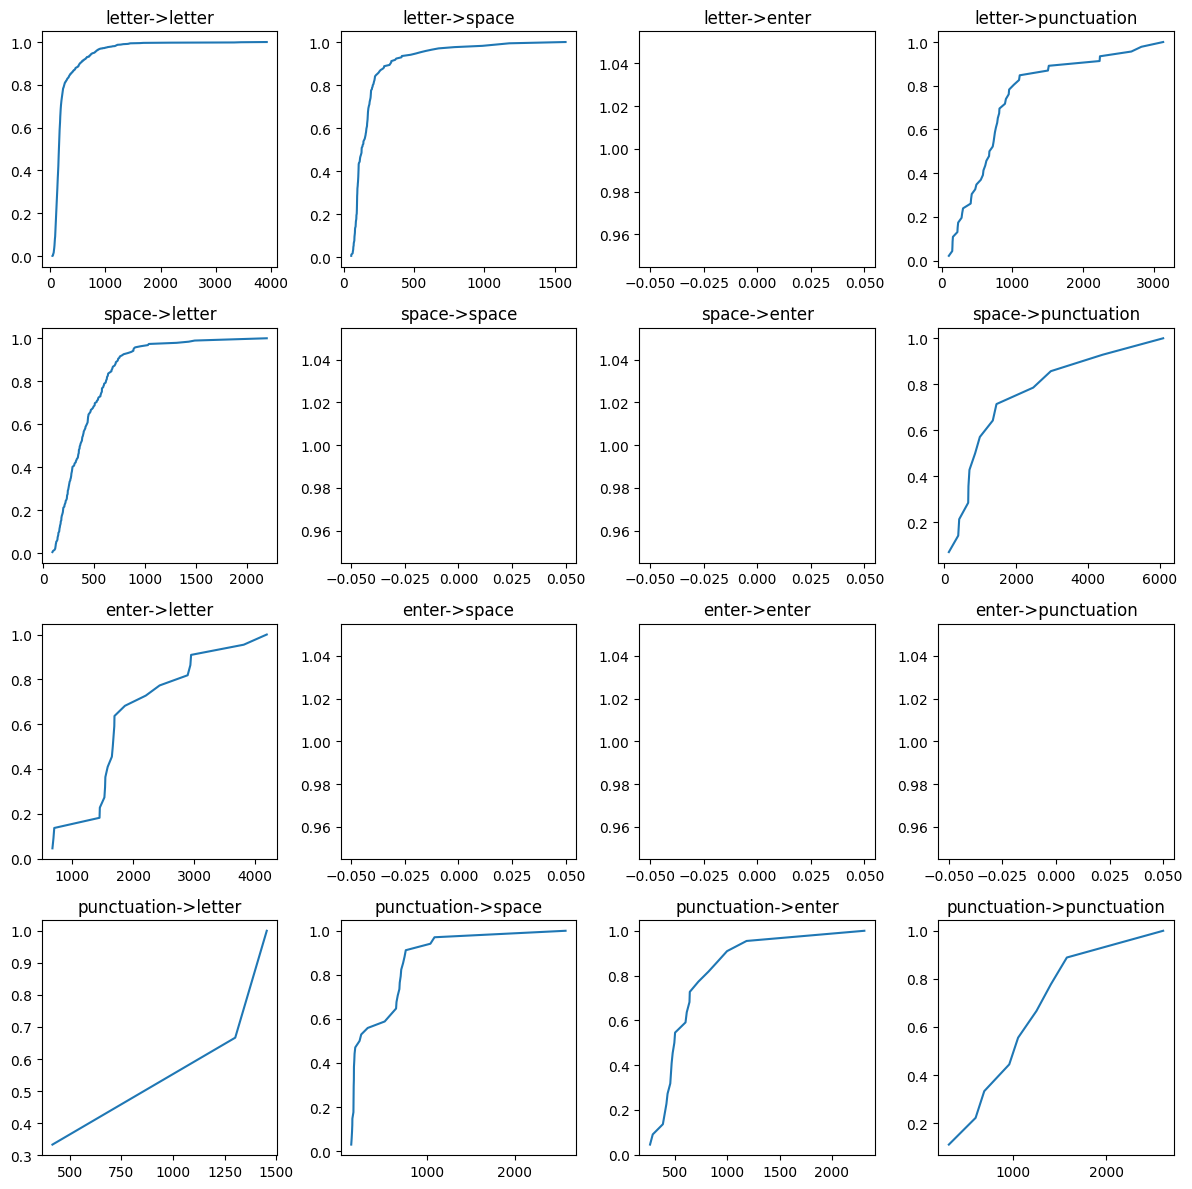

In [ ]:
fig, axes = plt.subplots(count, count, figsize=(12, 12))
cdfs = []
distribution_values = []

for code in range(len(data)):
  i, j = from_transition_code(code)
  distribution = np.array(data[code])
  time, freq = np.unique(distribution, return_counts=True)
  order = time.argsort()
  time, freq = time[order], freq[order]
  cdf = freq.cumsum().astype(np.float64)
  cdf /= freq.sum()

  if(len(cdf) == 0):
    cdf = np.array([1])
    time = np.array([0])

  cdfs.append(cdf)
  distribution_values.append(time)

  axes[i, j].set_title(str(categories[i]) + '->' + str(categories[j]))
  axes[i, j].plot(time, cdf)

plt.tight_layout()
plt.show()

Small math interlude:

Let $F$ be a distribution function. That means
1. $F$ is monotonously increasing
2. $F$ is right continuous
3. $\lim_{x\to -\infty} F(x) = 0$
4. $\lim_{x\to \infty} F(x) = 1$

$$X: [0,1] \to \mathbb{R}, t \mapsto \inf\{x:F(x) \geq t\}$$

We notice the following:
$$\inf\{x:F(x) \geq t\} \leq a \Leftrightarrow F(a) \geq t$$

The backward direction is trivial so we only check the forward one:

Let $M = \inf\{x:F(x) \geq t\} \leq a$. Then for all $\delta > 0$ we can find such $x$ in a feasible set that $x - M < \delta$. Pick $\varepsilon = F(a) - F(M)$, which is non-negative by monotonicity of $F$. Right continuity of $F$ ensures, that there exists $\delta > 0$, s.t. $F(y) - F(M) < \varepsilon$ for all $M \leq y < M + \delta$. In particular it holds that $F(x) - F(M) < \varepsilon = F(a) - F(M)$, so $F(a) > F(x) \geq t$

We hence conclude that $X^{-1}((-\infty;a]) = [0;F(a)]$, so the mapping $X$ is $[0;1]\doublecap \mathcal{B}_1 \to \mathcal{B}_1$ measurable, since the preimage under $X$ of the generating set of $\mathcal{B}_1$ lies in $[0;1]\doublecap \mathcal{B}_1$

Also we have that $\lambda(X^{-1}((-\infty;a])) = F(a)$, so the push-forward measure induced by $X$ has the distribution $F$

We have that the probability measure induced by the uniform distribution on a unit interval is exactly Lebesgue measure restricted to $[0;1]$. We define $Y(\omega) = \inf\{x:F(x) \geq U(\omega)\}$, and observe the following:

$$Y(\omega)\leq a \Leftrightarrow U(\omega) \leq F(a)$$

Therefore:
$$\mathbb{P}(Y \leq a) = \mathbb{P}(U(\omega) \leq F(a)) = F(a)$$
and $\mathbb{P}_Y \sim F$



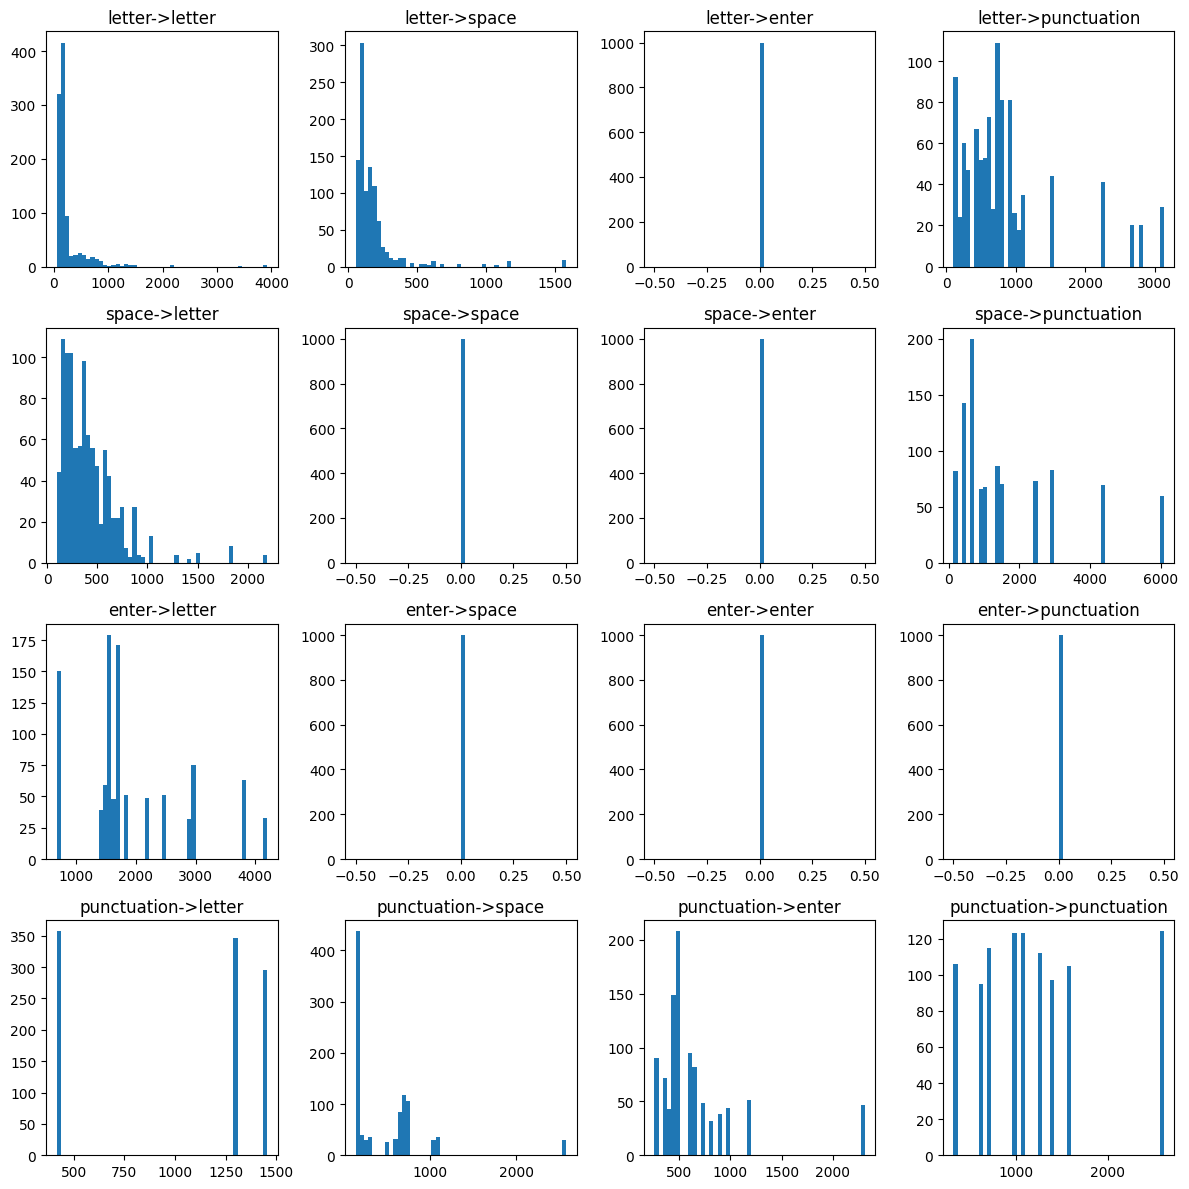

In [ ]:
def get_rv(t, values, cdf):
  indices = np.searchsorted(cdf, t, side = 'right') - 1
  return values[indices]

fig, axes = plt.subplots(count, count, figsize=(12, 12))
n = 1000

for code in range(len(data)):
  i, j = from_transition_code(code)
  cdf = cdfs[code]
  distr = distribution_values[code]
  t = np.random.rand(n)
  values = get_rv(t, distr, cdf)

  axes[i, j].set_title(str(categories[i]) + '->' + str(categories[j]))
  axes[i, j].hist(values, bins = 50)

plt.tight_layout()
plt.show()

What we did is basically computed the condtional distribution of $X$, represnting the time between two key presses. Formally:
$$X_{ij} \sim \mathbb{P}(X \mid \text{prev key} = i, \text{current key} = j)$$